In [2]:
!echo $X509_USER_PROXY
!voms-proxy-info -all
uid = !echo ${UID}

import os
os.environ["X509_USER_PROXY"] = f"/tmp/x509up_u{uid[0]}"

!voms-proxy-info -all

/uscms/home/lzygala/x509up_u55101
subject   : /DC=ch/DC=cern/OU=Organic Units/OU=Users/CN=lzygala/CN=830113/CN=Lara Zygala/CN=235827009
issuer    : /DC=ch/DC=cern/OU=Organic Units/OU=Users/CN=lzygala/CN=830113/CN=Lara Zygala
identity  : /DC=ch/DC=cern/OU=Organic Units/OU=Users/CN=lzygala/CN=830113/CN=Lara Zygala
type      : RFC compliant proxy
strength  : 2048 bits
path      : /uscms/home/lzygala/x509up_u55101
timeleft  : 0:00:00
key usage : Digital Signature, Key Encipherment
subject   : /DC=ch/DC=cern/OU=Organic Units/OU=Users/CN=lzygala/CN=830113/CN=Lara Zygala/CN=604745234
issuer    : /DC=ch/DC=cern/OU=Organic Units/OU=Users/CN=lzygala/CN=830113/CN=Lara Zygala
identity  : /DC=ch/DC=cern/OU=Organic Units/OU=Users/CN=lzygala/CN=830113/CN=Lara Zygala
type      : RFC compliant proxy
strength  : 2048 bits
path      : /tmp/x509up_u55101
timeleft  : 187:38:02
key usage : Digital Signature, Key Encipherment
=== VO cms extension information ===
VO        : cms
subject   : /DC=ch/DC=cern/OU=

In [3]:
from coffea.nanoevents import NanoEventsFactory
import awkward as ak
import numpy as np
import hist
import pandas as pd
import uproot
import json
import glob
import matplotlib.pyplot as plt

In [4]:
def blocks(lines):
    lines = iter(lines)
    tag, block = "", []
    try:
        while True:
            line = next(lines)
            begintag = "# BEGIN "
            if line.startswith(begintag):
                tag = line[len(begintag):]
                block = []
            elif line.startswith("# END "):
                yield tag, block
            elif len(line):
                block.append(line)
    except StopIteration:
        pass


def tohist(block):
    assert block[0] == '# xlow   xhigh   val   errminus  errplus'
    data = np.fromstring(" ".join(block[1:]), sep=" ").reshape(-1, 5)
    assert np.all(data[1:, 0] == data[:-1, 1])
    edges = np.concatenate([data[:, 0], data[-1:, 1]])
    val, lo, hi = data[:, 2:].T
    h = hist.Hist.new.Var(edges).Weight()
    h.view().value = val
    h.view().variance = (hi - lo)**2 / 4
    return h


def load_yoda(lines):
    hists = {}
    data = {}
    for tag, block in blocks(lines.split("\n")):
        if tag.startswith("HISTO1D"):
            hists[tag[8:]] = tohist(block)
        elif tag.startswith("DATA"):
            for l in block:
                k, v = l.split("=")
                data[k] = v
    return data, hists

In [5]:
from pathlib import Path
# https://gitlab.cern.ch/jlindert/vjets_dm

eejmeta, eej = load_yoda(Path("data/vjets/eej.dat").read_text())
vvjmeta, vvj = load_yoda(Path("data/vjets/vvj.dat").read_text())
evjmeta, evj = load_yoda(Path("data/vjets/evj.dat").read_text())
lindert = dict(**eej, **vvj, **evj)

print(lindert.keys())

dict_keys(['eej_pTV_LO', 'eej_pTV_K_LO', 'eej_pTV_d1K_LO', 'eej_pTV_d2K_LO', 'eej_pTV_K_NLO', 'eej_pTV_NLO', 'eej_pTV_K_NNLO', 'eej_pTV_NNLO', 'eej_pTV_d1K_NLO', 'eej_pTV_d1K_NNLO', 'eej_pTV_d2K_NLO', 'eej_pTV_d2K_NNLO', 'eej_pTV_d3K_NLO', 'eej_pTV_d3K_NNLO', 'eej_pTV_kappa_NLO_EW', 'eej_pTV_kappa_NNLO_Sud', 'eej_pTV_kappa_EW', 'eej_pTV_d1kappa_EW', 'eej_pTV_d2kappa_EW', 'eej_pTV_d3kappa_EW', 'eej_pTV_dK_NLO_mix', 'eej_pTV_dK_NNLO_mix', 'eej_pTV_gammaind_LO', 'eej_pTV_dK_PDF_1', 'eej_pTV_dK_PDF_2', 'eej_pTV_dK_PDF_3', 'eej_pTV_dK_PDF_4', 'eej_pTV_dK_PDF_5', 'eej_pTV_dK_PDF_6', 'eej_pTV_dK_PDF_7', 'eej_pTV_dK_PDF_8', 'eej_pTV_dK_PDF_9', 'eej_pTV_dK_PDF_10', 'eej_pTV_dK_PDF_11', 'eej_pTV_dK_PDF_12', 'eej_pTV_dK_PDF_13', 'eej_pTV_dK_PDF_14', 'eej_pTV_dK_PDF_15', 'eej_pTV_dK_PDF_16', 'eej_pTV_dK_PDF_17', 'eej_pTV_dK_PDF_18', 'eej_pTV_dK_PDF_19', 'eej_pTV_dK_PDF_20', 'eej_pTV_dK_PDF_21', 'eej_pTV_dK_PDF_22', 'eej_pTV_dK_PDF_23', 'eej_pTV_dK_PDF_24', 'eej_pTV_dK_PDF_25', 'eej_pTV_dK_PDF_26',

In [6]:


def make_lindert_pred(process, order):
    """Eqn. 76 of https://arxiv.org/pdf/1705.04664.pdf
    
    process: eej, evj, vvj; order: NLO, NNLO
    """
    sigma_lo = lindert[f"{process}_pTV_LO"].values()
    kqcd = lindert[f"{process}_pTV_K_{order}"].values()
    deltas = np.empty((3 + 106, len(kqcd)))
    kewk = lindert[f"{process}_pTV_kappa_EW"].values()
    deltas_ew = np.empty((3, len(kqcd)))
    delta_mix = lindert[f"{process}_pTV_dK_{order}_mix"].values()[None, :]

    for i in range(3):
        deltas[i, :] = lindert[f"{process}_pTV_d{i + 1}K_{order}"].values()

    for i in range(106):
        deltas[i + 3, :] = lindert[f"{process}_pTV_dK_PDF_{i + 1}"].values()

    for i in range(3):
        deltas_ew[i, :] = lindert[f"{process}_pTV_d{i + 1}kappa_EW"].values()

    def pred(epsilon, ew=True):
        """epsilon: (*, 3 + 106 + 3 + 1) (qcd scale, pdf, ewk variation, cross-term)"""
        Kth = (kqcd + epsilon[..., :109] @ deltas)
        if ew:
            Kth *= (1 + kewk + epsilon[..., 109:112] @ deltas_ew)
            Kth += epsilon[..., 112:113] @ delta_mix
        return Kth * sigma_lo
    
    return pred



/uscms/home/lzygala/nobackup/micromamba/envs/hbb_fit/lib/python3.10/site-packages/mplhep/error_estimation.py:49: RuntimeWarning: divide by zero encountered in divide
  counts = sumw / scale
/uscms/home/lzygala/nobackup/micromamba/envs/hbb_fit/lib/python3.10/site-packages/mplhep/error_estimation.py:49: RuntimeWarning: divide by zero encountered in divide
  counts = sumw / scale
/uscms/home/lzygala/nobackup/micromamba/envs/hbb_fit/lib/python3.10/site-packages/mplhep/error_estimation.py:49: RuntimeWarning: divide by zero encountered in divide
  counts = sumw / scale


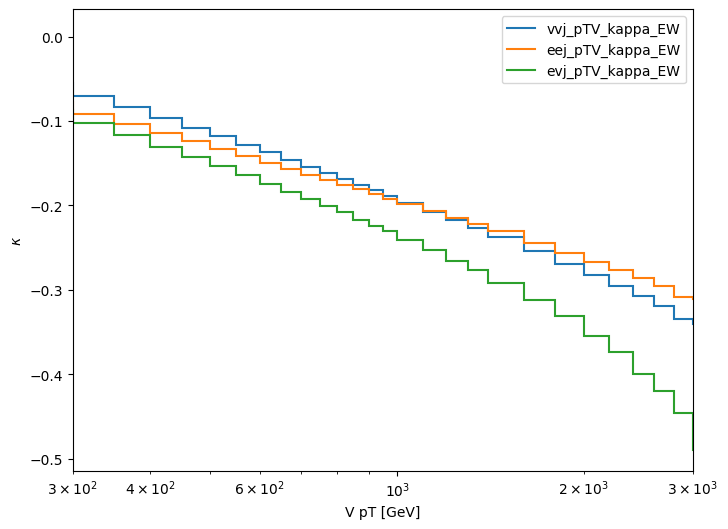

In [7]:
from scipy.interpolate import interp1d

def hinterp(h):
    ax = h.axes[0]
    return interp1d(ax.centers, h.view().value, bounds_error=False)

fig, ax = plt.subplots(figsize=(8, 6))

lindert["vvj_pTV_kappa_EW"].plot(ax=ax, label="vvj_pTV_kappa_EW", yerr=False)
lindert["eej_pTV_kappa_EW"].plot(ax=ax, label="eej_pTV_kappa_EW", yerr=False)
lindert["evj_pTV_kappa_EW"].plot(ax=ax, label="evj_pTV_kappa_EW", yerr=False)


ax.set_xscale("log")
ax.set_xlabel("V pT [GeV]")
ax.set_xlim(300, 3000)
ax.set_ylabel("$\kappa$")
ax.legend()

In [8]:

from coffea import processor
from hist.dask import Hist

class VPtProc(processor.ProcessorABC):
    edges = np.array([  30.,   40.,   50.,   60.,   70.,   80.,   90.,  100.,  110.,
        120.,  130.,  140.,  150.,  200.,  250.,  300.,  350.,  400.,
        450.,  500.,  550.,  600.,  650.,  700.,  750.,  800.,  850.,
        900.,  950., 1000., 1100., 1200., 1300., 1400., 1600., 1800.,
       2000., 2200., 2400., 2600., 2800., 3000., 6500.])

    def process(self, events):
        boson = ak.firsts(events.GenPart[
            ((events.GenPart.pdgId == 23)|(abs(events.GenPart.pdgId) == 24))
            & events.GenPart.hasFlags(["fromHardProcess", "isLastCopy"])
        ])
        vpt = ak.fill_none(boson.pt, 0.)
        offshell = events.GenPart[
            events.GenPart.hasFlags(["fromHardProcess", "isLastCopy"])
            & ak.is_none(boson)
            & (abs(events.GenPart.pdgId) >= 11) & (abs(events.GenPart.pdgId) <= 16)
        ].sum()
        scalevar = (
            Hist.new
            .IntCat(range(8))
            .Var(self.edges).Weight()
        )
        for i in range(8):
            scalevar.fill(i, vpt + offshell.pt, weight=events.genWeight * events.LHEScaleWeight[:, i])

        return {
            
                "Vpt_resonant": (
                    Hist.new
                    .Var(self.edges).Weight()
                    .fill(vpt, weight=events.genWeight)
                ),
                "Vpt_nano": (
                    Hist.new
                    .Var(self.edges).Weight()
                    .fill(events.LHE.Vpt, weight=events.genWeight)
                ),
                "Vpt": (
                    Hist.new
                    .Var(self.edges).Weight()
                    .fill(vpt + offshell.pt, weight=events.genWeight)
                ),
                "Vptscale": scalevar,
                "Vmass": (
                    Hist.new
                    .StrCat(["V", "offshell"])
                    .Reg(105, 30, 240, name="mass")
                    .Weight()
                    .fill("V", ak.fill_none(boson.mass, 0.), weight=events.genWeight)
                    .fill("offshell", offshell.mass, weight=events.genWeight)
                ),
                "sumw": ak.sum(events.genWeight),
            
        }

    def postprocess(self, x):
        return x
    
vptproc = VPtProc()


In [ ]:

from hbb.xsecs import xsecs
from hbb.run_utils import get_dataset_spec, get_fileset

xs = xsecs
year = "2024"

procs = {
    "VJets_lep_NLO":[
        "DYto2L-2Jets_MLL-50_PTLL-100to200_1J",
        "DYto2L-2Jets_MLL-50_PTLL-200to400_1J",
        "DYto2L-2Jets_MLL-50_PTLL-400to600_1J",
        "DYto2L-2Jets_MLL-50_PTLL-600_1J",
        "DYto2L-2Jets_MLL-50_PTLL-100to200_2J",
        "DYto2L-2Jets_MLL-50_PTLL-200to400_2J",
        "DYto2L-2Jets_MLL-50_PTLL-400to600_2J",
        "DYto2L-2Jets_MLL-50_PTLL-600_2J",

        "WtoLNu-2Jets_Bin-1J-PTLNu-40to100",
        "WtoLNu-2Jets_Bin-1J-PTLNu-100to200",
        "WtoLNu-2Jets_Bin-1J-PTLNu-200to400",
        "WtoLNu-2Jets_Bin-1J-PTLNu-400to600",
        "WtoLNu-2Jets_Bin-1J-PTLNu-600",
        "WtoLNu-2Jets_Bin-2J-PTLNu-40to100",
        "WtoLNu-2Jets_Bin-2J-PTLNu-100to200",
        "WtoLNu-2Jets_Bin-2J-PTLNu-200to400",
        "WtoLNu-2Jets_Bin-2J-PTLNu-400to600",
        "WtoLNu-2Jets_Bin-2J-PTLNu-600",
    ], 
    "VJets_had_LO":[
        "Zto2Q-4Jets_Bin-HT-100to400",
        "Zto2Q-4Jets_Bin-HT-400to800",
        "Zto2Q-4Jets_Bin-HT-800to1500",
        "Zto2Q-4Jets_Bin-HT-1500to2500",
        "Zto2Q-4Jets_Bin-HT-2500",

        "Wto2Q-3Jets_Bin-HT-100to400",
        "Wto2Q-3Jets_Bin-HT-400to800",
        "Wto2Q-3Jets_Bin-HT-800to1500",
        "Wto2Q-3Jets_Bin-HT-1500to2500",
        "Wto2Q-3Jets_Bin-HT-2500", 
    ]
}

In [ ]:
import datetime
import time
import json
import coffea.util

from coffea.dataset_tools import apply_to_fileset, max_chunks, max_files, preprocess

import dask
from coffea import nanoevents
import os


now = datetime.datetime.now().strftime("%Y%m%d")

outdir = f"data/vjets/{now}"
if not os.path.exists(outdir):
        os.makedirs(outdir)

for proc in procs:
    for subsamp in procs[proc]:
        tic = time.time()
        outfile = f"{outdir}/run_{proc}_{subsamp}.coffea"
        if os.path.isfile(outfile):
                print("File " + outfile + " already exists. Skipping.")
                continue
        
        print(f"Beginning Process {proc} Subsample {subsamp}")

        fileset = get_fileset(
            year=year,
            version="v15",
            samples=[proc],
            subsamples=[subsamp],
            starti= 0,
            endi= -1,
        )

        dict_process_files = get_dataset_spec(fileset)

        print(f"\tLoaded fileset")

        preprocessed_available, preprocessed_total = preprocess(
            dict_process_files,
            align_clusters=True,
            skip_bad_files=True,
            recalculate_steps=False,
            files_per_batch=1,
            file_exceptions=(OSError,),
            step_size=100_000,
            save_form=False,
            uproot_options={
                "xrootd_handler": uproot.source.xrootd.MultithreadedXRootDSource,
                "allow_read_errors_with_report": True,
            },
            step_size_safety_factor=0.5,
        )

        print(f"\tFinished Preprocessing")

        full_tg, rep = apply_to_fileset(
            data_manipulation=vptproc,
            fileset=max_chunks(preprocessed_available, 300),
            schemaclass=nanoevents.NanoAODSchema,
            uproot_options={
                "allow_read_errors_with_report": (OSError, KeyError),
                "xrootd_handler": uproot.source.xrootd.MultithreadedXRootDSource,
                "timeout": 1800,
            },
        )

        print(f"\tStarting Computation")


        output, _ = dask.compute(full_tg, rep)

        coffea.util.save(output, outfile)

        print(f"\tSaved file {outfile}")
        print(f"\tProcessing time: {(time.time() - tic) / 60.0} minutes")
        

File data/vjets/20260325/run_VJets_lep_NLO_DYto2L-2Jets_MLL-50_PTLL-100to200_1J.coffea already exists. Skipping.
File data/vjets/20260325/run_VJets_lep_NLO_DYto2L-2Jets_MLL-50_PTLL-200to400_1J.coffea already exists. Skipping.
File data/vjets/20260325/run_VJets_lep_NLO_DYto2L-2Jets_MLL-50_PTLL-400to600_1J.coffea already exists. Skipping.
File data/vjets/20260325/run_VJets_lep_NLO_DYto2L-2Jets_MLL-50_PTLL-600_1J.coffea already exists. Skipping.
File data/vjets/20260325/run_VJets_lep_NLO_DYto2L-2Jets_MLL-50_PTLL-100to200_2J.coffea already exists. Skipping.
File data/vjets/20260325/run_VJets_lep_NLO_DYto2L-2Jets_MLL-50_PTLL-200to400_2J.coffea already exists. Skipping.
File data/vjets/20260325/run_VJets_lep_NLO_DYto2L-2Jets_MLL-50_PTLL-400to600_2J.coffea already exists. Skipping.
File data/vjets/20260325/run_VJets_lep_NLO_DYto2L-2Jets_MLL-50_PTLL-600_2J.coffea already exists. Skipping.
Beginning Process VJets_lep_NLO Subsample WtoLNu-2Jets_Bin-1J-PTLNu-40to100
	Loaded fileset
	Finished Prep

In [14]:
print(output)

{'DYto2L-2Jets_MLL-50_PTLL-200to400_2J': {'Vpt_resonant': Hist(Variable(array([  30.,   40.,   50.,   60.,   70.,   80.,   90.,  100.,  110.,
        120.,  130.,  140.,  150.,  200.,  250.,  300.,  350.,  400.,
        450.,  500.,  550.,  600.,  650.,  700.,  750.,  800.,  850.,
        900.,  950., 1000., 1100., 1200., 1300., 1400., 1600., 1800.,
       2000., 2200., 2400., 2600., 2800., 3000., 6500.]), label='Axis 0'), storage=Weight()) # Sum: WeightedSum(value=5.82458e+08, variance=1.10827e+11) (WeightedSum(value=6.24688e+08, variance=1.18883e+11) with flow), 'Vpt_nano': Hist(Variable(array([  30.,   40.,   50.,   60.,   70.,   80.,   90.,  100.,  110.,
        120.,  130.,  140.,  150.,  200.,  250.,  300.,  350.,  400.,
        450.,  500.,  550.,  600.,  650.,  700.,  750.,  800.,  850.,
        900.,  950., 1000., 1100., 1200., 1300., 1400., 1600., 1800.,
       2000., 2200., 2400., 2600., 2800., 3000., 6500.]), label='Axis 0'), storage=Weight()) # Sum: WeightedSum(value=6.246

In [18]:


import coffea.util
from pathlib import Path

indir = Path(f"data/vjets/20260325")

loaded_files = []
for file in indir.glob('*.coffea'):
    if file.is_file():
        loaded_files.append(coffea.util.load(file))

res = processor.accumulate(loaded_files)



In [19]:

for ds, plots in res.items():
    print("------------------")
    print("------------------")
    print(ds)
    print("------------------")
    print(plots)
    print("------------------")

------------------
------------------
DYto2L-2Jets_MLL-50_PTLL-100to200_1J
------------------
{'Vpt_resonant': Hist(Variable(array([  30.,   40.,   50.,   60.,   70.,   80.,   90.,  100.,  110.,
        120.,  130.,  140.,  150.,  200.,  250.,  300.,  350.,  400.,
        450.,  500.,  550.,  600.,  650.,  700.,  750.,  800.,  850.,
        900.,  950., 1000., 1100., 1200., 1300., 1400., 1600., 1800.,
       2000., 2200., 2400., 2600., 2800., 3000., 6500.]), label='Axis 0'), storage=Weight()) # Sum: WeightedSum(value=7.25512e+09, variance=6.42756e+12) (WeightedSum(value=7.6696e+09, variance=6.79414e+12) with flow), 'Vpt_nano': Hist(Variable(array([  30.,   40.,   50.,   60.,   70.,   80.,   90.,  100.,  110.,
        120.,  130.,  140.,  150.,  200.,  250.,  300.,  350.,  400.,
        450.,  500.,  550.,  600.,  650.,  700.,  750.,  800.,  850.,
        900.,  950., 1000., 1100., 1200., 1300., 1400., 1600., 1800.,
       2000., 2200., 2400., 2600., 2800., 3000., 6500.]), label='Axis 0

In [20]:
scaled = {}
for ds, plots in res.items():
    if ds not in xs:
        continue
    xsw = xs[ds] / plots["sumw"]
    lum = plots["Vpt_nano"].sum(flow=True)
    sds = {
        "samples": {(ds, xs[ds], lum.value**2 / lum.variance / xs[ds] / 1000)}
    }
    for name, h in plots.items():
        if isinstance(h, hist.Hist):
            h = h.copy()
            h.view().value *= xsw
            h.view().variance *= xsw**2
            if "Vpt" in name:
                h.view().value /= h.axes[-1].widths
                h.view().variance /= h.axes[-1].widths**2
            sds[name] = h
    scaled[ds] = sds

In [21]:
print("\n".join(scaled))

DYto2L-2Jets_MLL-50_PTLL-100to200_1J
DYto2L-2Jets_MLL-50_PTLL-200to400_1J
DYto2L-2Jets_MLL-50_PTLL-400to600_1J
DYto2L-2Jets_MLL-50_PTLL-600_1J
DYto2L-2Jets_MLL-50_PTLL-100to200_2J
DYto2L-2Jets_MLL-50_PTLL-200to400_2J
DYto2L-2Jets_MLL-50_PTLL-400to600_2J
DYto2L-2Jets_MLL-50_PTLL-600_2J
Zto2Q-4Jets_Bin-HT-100to400
Zto2Q-4Jets_Bin-HT-400to800
Zto2Q-4Jets_Bin-HT-800to1500
Zto2Q-4Jets_Bin-HT-1500to2500
Zto2Q-4Jets_Bin-HT-2500
Wto2Q-3Jets_Bin-HT-100to400
Wto2Q-3Jets_Bin-HT-400to800
Wto2Q-3Jets_Bin-HT-800to1500
Wto2Q-3Jets_Bin-HT-1500to2500
Wto2Q-3Jets_Bin-HT-2500
WtoLNu-2Jets_Bin-1J-PTLNu-200to400
WtoLNu-2Jets_Bin-1J-PTLNu-400to600
WtoLNu-2Jets_Bin-1J-PTLNu-600
WtoLNu-2Jets_Bin-2J-PTLNu-200to400
WtoLNu-2Jets_Bin-2J-PTLNu-400to600
WtoLNu-2Jets_Bin-2J-PTLNu-600
WtoLNu-2Jets_Bin-1J-PTLNu-40to100
WtoLNu-2Jets_Bin-1J-PTLNu-100to200
WtoLNu-2Jets_Bin-2J-PTLNu-40to100
WtoLNu-2Jets_Bin-2J-PTLNu-100to200


In [22]:
cms_zqqj_mlm = processor.accumulate([v for k, v in scaled.items() if "Zto2Q" in k])
cms_wqqj_mlm = processor.accumulate([v for k, v in scaled.items() if "Wto2Q" in k])
cms_zll_nlo = processor.accumulate([v for k, v in scaled.items() if "DYto2L" in k])
cms_wlv_nlo = processor.accumulate([v for k, v in scaled.items() if "WtoLNu" in k])

In [27]:
df = pd.DataFrame(
    sorted(("CMS Z(qq)+4j MLM",) + tup for tup in cms_zqqj_mlm["samples"])
    + sorted(("CMS W(qq)+3j MLM",) + tup  for tup in cms_wqqj_mlm["samples"])
    + sorted(("CMS Z(ll)+2j NLO",) + tup  for tup in cms_zll_nlo["samples"])
    + sorted(("CMS W(lv)+2j NLO",) + tup  for tup in cms_wlv_nlo["samples"]),
    columns=["Sample", "PD component", "$\sigma$ [pb]", "Effective lumi [1/fb]"]
)

df.set_index(["Sample", "PD component"])

$\sigma$ [pb]  \
Sample           PD component                                          
CMS Z(qq)+4j MLM Zto2Q-4Jets_Bin-HT-100to400              6328.00000   
                 Zto2Q-4Jets_Bin-HT-1500to2500               0.84960   
                 Zto2Q-4Jets_Bin-HT-2500                     0.05672   
                 Zto2Q-4Jets_Bin-HT-400to800               145.10000   
                 Zto2Q-4Jets_Bin-HT-800to1500               12.93000   
CMS W(qq)+3j MLM Wto2Q-3Jets_Bin-HT-100to400             16120.00000   
                 Wto2Q-3Jets_Bin-HT-1500to2500               1.85200   
                 Wto2Q-3Jets_Bin-HT-2500                     0.11770   
                 Wto2Q-3Jets_Bin-HT-400to800               354.20000   
                 Wto2Q-3Jets_Bin-HT-800to1500               29.60000   
CMS Z(ll)+2j NLO DYto2L-2Jets_MLL-50_PTLL-100to200_1J       45.42000   
                 DYto2L-2Jets_MLL-50_PTLL-100to200_2J       51.68000   
                 DYto2L-2Jets_MLL-50_PTLL-200to400_1J        3.38200   
                 DYto2L-2Jets_MLL-50_PTLL-200to400_2J        7.15900   
                 DYto2L-2Jets_MLL-50_PTLL-400to600_1J        0.11620   
                 DYto2L-2Jets_MLL-50_PTLL-400to600_2J        0.41570   
                 DYto2L-2Jets_MLL-50_PTLL-600_1J             0.01392   
                 DYto2L-2Jets_MLL-50_PTLL-600_2J             0.07019   
CMS W(lv)+2j NLO WtoLNu-2Jets_Bin-1J-PTLNu-100to200        342.30000   
                 WtoLNu-2Jets_Bin-1J-PTLNu-200to400         21.84000   
                 WtoLNu-2Jets_Bin-1J-PTLNu-400to600          0.68450   
                 WtoLNu-2Jets_Bin-1J-PTLNu-40to100        4211.00000   
                 WtoLNu-2Jets_Bin-1J-PTLNu-600               0.07753   
                 WtoLNu-2Jets_Bin-2J-PTLNu-100to200        411.10000   
                 WtoLNu-2Jets_Bin-2J-PTLNu-200to400         53.59000   
                 WtoLNu-2Jets_Bin-2J-PTLNu-400to600          3.09900   
                 WtoLNu-2Jets_Bin-2J-PTLNu-40to100        1581.00000   
                 WtoLNu-2Jets_Bin-2J-PTLNu-600               0.52590   

                                                       Effective lumi [1/fb]  
Sample           PD component                                                 
CMS Z(qq)+4j MLM Zto2Q-4Jets_Bin-HT-100to400                        4.027151  
                 Zto2Q-4Jets_Bin-HT-1500to2500                  23517.747879  
                 Zto2Q-4Jets_Bin-HT-2500                       267207.606358  
                 Zto2Q-4Jets_Bin-HT-400to800                      171.579289  
                 Zto2Q-4Jets_Bin-HT-800to1500                    1409.779426  
CMS W(qq)+3j MLM Wto2Q-3Jets_Bin-HT-100to400                        1.478885  
                 Wto2Q-3Jets_Bin-HT-1500to2500                  10778.929654  
                 Wto2Q-3Jets_Bin-HT-2500                       181576.294303  
                 Wto2Q-3Jets_Bin-HT-400to800                       69.108980  
                 Wto2Q-3Jets_Bin-HT-800to1500                     703.555947  
CMS Z(ll)+2j NLO DYto2L-2Jets_MLL-50_PTLL-100to200_1J             190.617632  
                 DYto2L-2Jets_MLL-50_PTLL-100to200_2J              57.965946  
                 DYto2L-2Jets_MLL-50_PTLL-200to400_1J            2502.540749  
                 DYto2L-2Jets_MLL-50_PTLL-200to400_2J             458.513690  
                 DYto2L-2Jets_MLL-50_PTLL-400to600_1J           41457.410325  
                 DYto2L-2Jets_MLL-50_PTLL-400to600_2J            3728.510814  
                 DYto2L-2Jets_MLL-50_PTLL-600_1J               377253.712091  
                 DYto2L-2Jets_MLL-50_PTLL-600_2J                25367.735601  
CMS W(lv)+2j NLO WtoLNu-2Jets_Bin-1J-PTLNu-100to200                23.209473  
                 WtoLNu-2Jets_Bin-1J-PTLNu-200to400               489.868315  
                 WtoLNu-2Jets_Bin-1J-PTLNu-400to600              9972.303738  
                 WtoLNu-2Jets_Bin-1J-PTLNu-40to100                  1.231014 

In [47]:
plotdir = f"data/vjets/plots"
if not os.path.exists(plotdir):
        os.makedirs(plotdir)

/uscms/home/lzygala/nobackup/micromamba/envs/hbb_fit/lib/python3.10/site-packages/mplhep/error_estimation.py:49: RuntimeWarning: divide by zero encountered in divide
  counts = sumw / scale


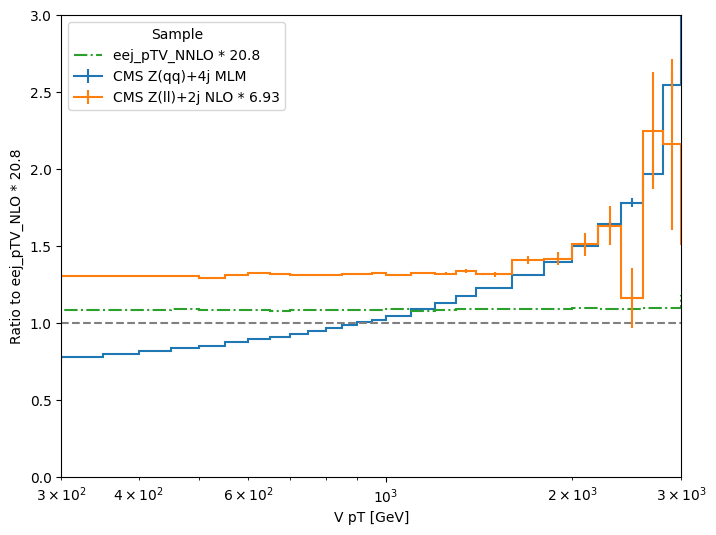

In [53]:
fig, ax = plt.subplots(figsize=(8, 6), facecolor="w")

name = "Vpt"
den = lindert["eej_pTV_NLO"].values() * 20.8
ax.axhline(1, color="grey", linestyle="--")

def scale(h, s):
    h = h.copy()
    h.view().value *= s
    h.view().variance *= s**2
    return h


scale(cms_zqqj_mlm[name], 1 / den).plot1d(label="CMS Z(qq)+4j MLM")
scale(cms_zll_nlo[name], 6.93 / den).plot1d(label="CMS Z(ll)+2j NLO * 6.93")

scale(lindert["eej_pTV_NNLO"], 20.8 / den).plot1d(yerr=False, linestyle="-.", label="eej_pTV_NNLO * 20.8")

ax.set_xscale("log")
ax.set_xlim(300, 3000)
ax.set_ylim(0., 3.)
ax.set_ylabel("Ratio to eej_pTV_NLO * 20.8")
ax.set_xlabel("V pT [GeV]")
ax.legend(title="Sample", loc="upper left")

fig.savefig(f"{plotdir}/ZqqPt_vs_lindertNLO.pdf")

/uscms/home/lzygala/nobackup/micromamba/envs/hbb_fit/lib/python3.10/site-packages/mplhep/error_estimation.py:49: RuntimeWarning: divide by zero encountered in divide
  counts = sumw / scale


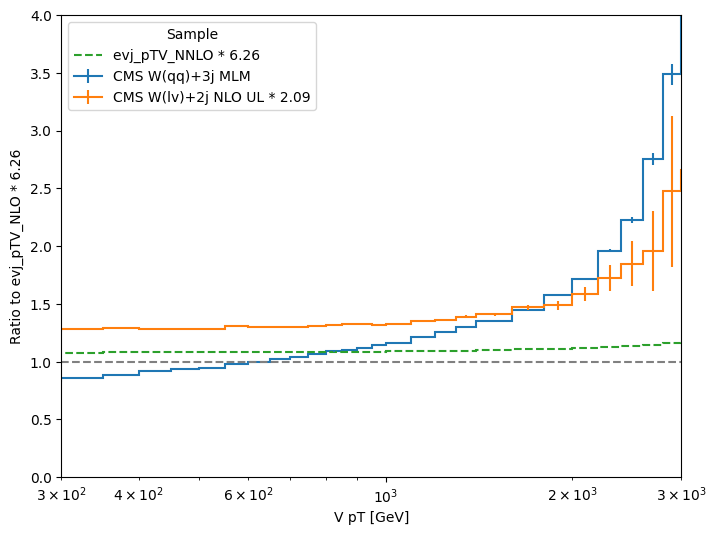

In [54]:
fig, ax = plt.subplots(figsize=(8, 6))

name = "Vpt"
den = lindert["evj_pTV_NLO"].values() * 6.26
ax.axhline(1, color="grey", linestyle="--")

scale(cms_wqqj_mlm[name], 1 / den).plot1d(label="CMS W(qq)+3j MLM")
scale(cms_wlv_nlo[name], 2.09 / den).plot1d(label="CMS W(lv)+2j NLO UL * 2.09")

scale(lindert["evj_pTV_NNLO"], 6.26 / den).plot1d(yerr=False, linestyle="--", label="evj_pTV_NNLO * 6.26")

ax.set_xscale("log")
ax.set_xlim(300, 3000)
ax.set_ylim(0., 4.0)
ax.set_ylabel("Ratio to evj_pTV_NLO * 6.26")
ax.set_xlabel("V pT [GeV]")
ax.legend(title="Sample", loc="upper left")

fig.savefig(f"{plotdir}/WqqPt_vs_lindertNLO.pdf")

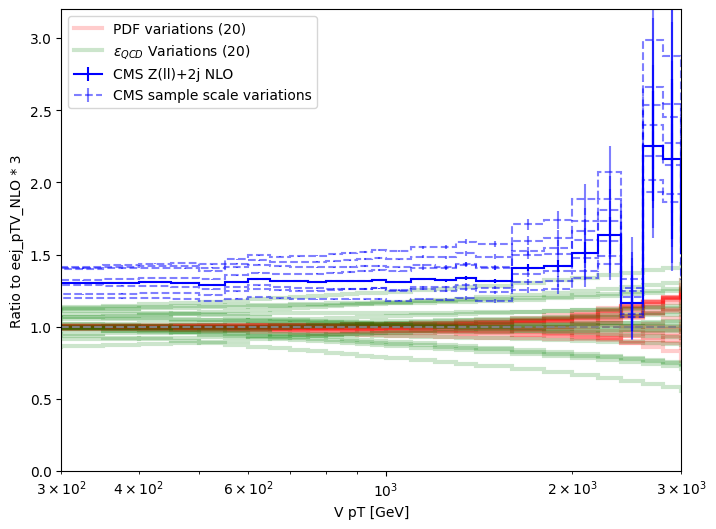

In [58]:
fig, ax = plt.subplots(figsize=(8, 6))

order = "NLO"
eej_qcd = make_lindert_pred("eej", order)
den = eej_qcd(np.zeros(113), ew=False) * 3
ax.axhline(1, color="grey", linestyle="--")

def scale(h, s):
    h = h.copy()
    h.view().value *= s
    h.view().variance *= s**2
    return h

systs = np.random.normal(size=(20, 113))
systs[:, :3] = 0.
reps = eej_qcd(systs, ew=False) * 3 / den
for i, rep in enumerate(reps):
    ax.stairs(rep, vptproc.edges, color="r", alpha=0.2, linewidth=3, 
              label="PDF variations (20)" if i==0 else None)

systs = np.random.normal(size=(20, 113))
systs[:, 3:] = 0.
reps = eej_qcd(systs, ew=False) * 3 / den
for i, rep in enumerate(reps):
    ax.stairs(rep, vptproc.edges, color="g", alpha=0.2, linewidth=3, 
              label="$\epsilon_{QCD}$ Variations (20)" if i==0 else None)
    
scale(cms_zll_nlo["Vpt"], 1 / den).plot1d(label="CMS Z(ll)+2j NLO", color="b")
scalevar = scale(cms_zll_nlo["Vptscale"], 1 / den)
for i in range(8):
    scalevar[i, :].plot1d(ax=ax, color="b", alpha=0.5, linestyle="--",
                            label="CMS sample scale variations" if i==0 else None
                           )

ax.set_xscale("log")
ax.set_xlim(300, 3000)
ax.set_ylim(0., 3.2)
ax.set_ylabel(f"Ratio to eej_pTV_{order} * 3")
ax.set_xlabel("V pT [GeV]")
ax.legend(loc="upper left")

fig.savefig(f"{plotdir}/ZPtFXFX_vs_lindert{order}.pdf")

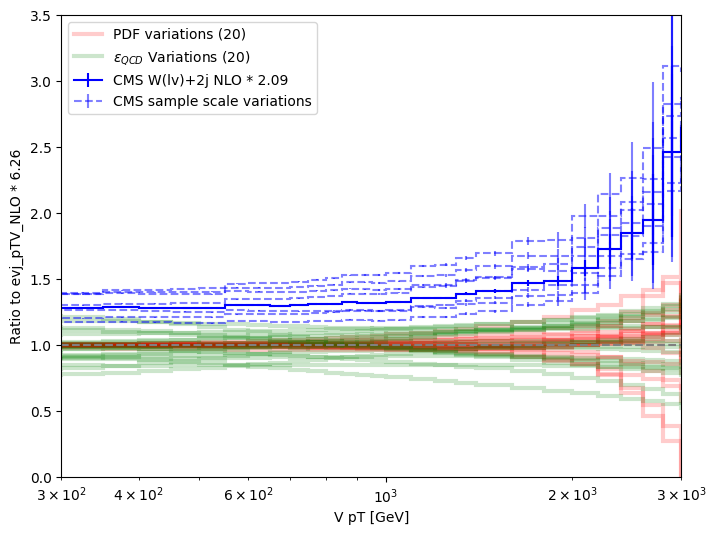

In [61]:
fig, ax = plt.subplots(figsize=(8, 6))

order = "NLO"
evj_qcd = make_lindert_pred("evj", order)
den = evj_qcd(np.zeros(113), ew=False) * 6.26
ax.axhline(1, color="grey", linestyle="--")


systs = np.random.normal(size=(20, 113))
systs[:, :3] = 0.
reps = evj_qcd(systs, ew=False) * 6.26 / den
for i, rep in enumerate(reps):
    ax.stairs(rep, vptproc.edges, color="r", alpha=0.2, linewidth=3, 
              label="PDF variations (20)" if i==0 else None)

systs = np.random.normal(size=(20, 113))
systs[:, 3:] = 0.
reps = evj_qcd(systs, ew=False) * 6.26 / den
for i, rep in enumerate(reps):
    ax.stairs(rep, vptproc.edges, color="g", alpha=0.2, linewidth=3, 
              label="$\epsilon_{QCD}$ Variations (20)" if i==0 else None)

scale(cms_wlv_nlo[name], 2.09 / den).plot1d(label="CMS W(lv)+2j NLO * 2.09", color="b")
scalevar = scale(cms_wlv_nlo["Vptscale"], 2.09 / den)
for i in range(8):
    scalevar[i, :].plot1d(ax=ax, color="b", alpha=0.5, linestyle="--",
                            label="CMS sample scale variations" if i==0 else None
                           )

ax.set_xscale("log")
ax.set_xlim(300, 3000)
ax.set_ylim(0., 3.5)
ax.set_ylabel(f"Ratio to evj_pTV_{order} * 6.26")
ax.set_xlabel("V pT [GeV]")
ax.legend(loc="upper left")

fig.savefig(f"{plotdir}/WPtFXFX_vs_lindert{order}.pdf")

# Correction Derivation

In [62]:
from correctionlib.schemav2 import CorrectionSet, Correction, Variable
from correctionlib.convert import from_histogram
import correctionlib

def polyfit(h, deg, barycenter=0.5):
    x = h.axes[-1].edges[:-1] + np.diff(h.axes[-1].edges) * barycenter
    y = h.values()
    yerr = np.sqrt(h.variances())
    mask = (y > 0) & (yerr > 0)
    x, y, yerr = x[mask], y[mask], yerr[mask]
    return np.polyfit(np.log(x), y, deg, w=1/yerr)

def horner(v, xstr):
    if len(v) > 1:
        return f"({horner(v[:-1], xstr)})*{xstr} + {v[-1]}"
    return f"{v[0]}"

def ratio(num, den):
    val = num.view().value / den.view().value
    var = (
        num.view().variance / den.view().value**2
        + den.view().variance * num.view().value**2 / den.view().value**4
    )
    num = num.copy()
    num.view().value = val
    num.view().variance = var
    return num


def evaluator(corr):
    cset = CorrectionSet(schema_version=2, corrections=[corr])
    return np.vectorize(
        correctionlib.CorrectionSet(cset)[corr.name].evaluate,
    )

vptvar = Variable(
    name="vpt",
    type="real",
    description="Generated boson pT (status 62: fromHardProcess, isLastCopy) or sum(leptons).pt if virtual"
)

x = np.geomspace(300, 3000)


### ZJets Corrections

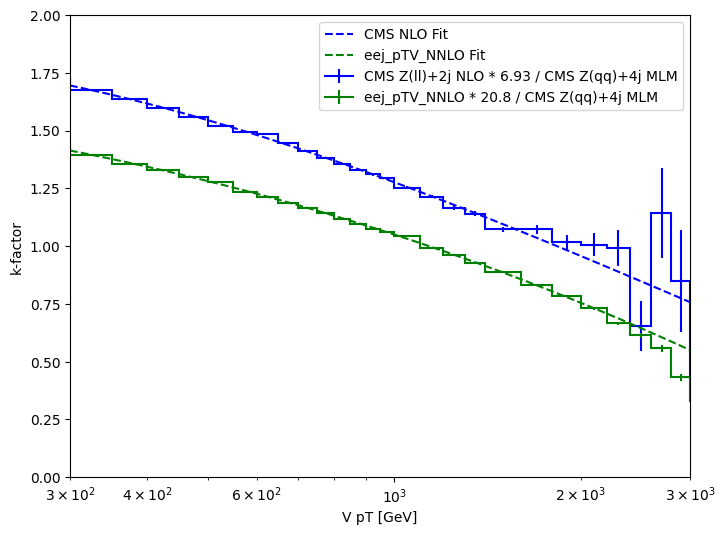

In [63]:
fig, ax = plt.subplots(figsize=(8, 6))

tofxfx = ratio(
    scale(cms_zll_nlo["Vpt"], 6.93),
    cms_zqqj_mlm["Vpt"],
)
tofxfx_fit = polyfit(tofxfx[hist.loc(300):], 3)
z_tofxfx_corr = Correction(
    name="Z_MLMtoFXFX",
    version=1,
    description="k_CMS(ptv), or CMS Z(ll)+2j NLO * 6.93 / CMS Z(qq)+4j MLM",
    inputs=[vptvar],
    output=Variable(name="out", type="real", description="Multiplicative k-factor"),
    data={
        "nodetype": "binning",
        "input": "vpt",
        "edges": [299, 300, 3000, 3001],
        "content": [
            np.polyval(tofxfx_fit, np.log(300)),
            {
                "nodetype": "formula",
                "variables": ["vpt"],
                "parser": "TFormula",
                "expression": horner(tofxfx_fit, "log(x)"),
            },
            np.polyval(tofxfx_fit, np.log(3000)),
        ],
        "flow": "clamp",
    },
)
tofxfx.plot1d(ax=ax, label="CMS Z(ll)+2j NLO * 6.93 / CMS Z(qq)+4j MLM", color="b")
ax.plot(x, evaluator(z_tofxfx_corr)(x), label="CMS NLO Fit", color="b", linestyle="--")


tolindert = ratio(
    scale(lindert["eej_pTV_NNLO"], 20.8),
    cms_zqqj_mlm["Vpt"],
)
tolindert_fit = polyfit(tolindert[hist.loc(300):], 3)
z_tolindert_corr = Correction(
    name="Z_MLMtoNNLOQCD",
    version=1,
    description="eej_pTV_NNLO * 20.8 / CMS Z(qq)+4j MLM",
    inputs=[vptvar],
    output=Variable(name="out", type="real", description="Multiplicative k-factor"),
    data={
        "nodetype": "binning",
        "input": "vpt",
        "edges": [299, 300, 3000, 3001],
        "content": [
            np.polyval(tolindert_fit, np.log(300)),
            {
                "nodetype": "formula",
                "variables": ["vpt"],
                "parser": "TFormula",
                "expression": horner(tolindert_fit, "log(x)"),
            },
            np.polyval(tolindert_fit, np.log(3000)),
        ],
        "flow": "clamp",
    },
)
tolindert.plot1d(ax=ax, label="eej_pTV_NNLO * 20.8 / CMS Z(qq)+4j MLM", color="g")
ax.plot(x, evaluator(z_tolindert_corr)(x), label="eej_pTV_NNLO Fit", color="g", linestyle="--")

ax.set_xscale("log")
ax.set_ylim(0, 2)
ax.set_xlim(300, 3000)
ax.set_ylabel("k-factor")
ax.set_xlabel("V pT [GeV]")
ax.legend()

fig.savefig(f"{plotdir}/Z_kCMS.pdf")

In [64]:
den = lindert["eej_pTV_LO"].values() * lindert["eej_pTV_K_NLO"].values()

def binning(idx, shift):
    epsilon = np.zeros(113)
    epsilon[idx] = shift
    return {
        "nodetype": "binning",
        "input": "vpt",
        "edges": list(vptproc.edges),
        "content": list(eej_qcd(epsilon) / den),
        "flow": "clamp",
    }


z_fixedorder_corr = Correction(
    name="Z_FixedOrderComponent",
    version=1,
    description="Z boson K_TH(vpt, ...) / K_NLO(vpt, ...)",
    inputs=[Variable(name="systematic", type="string"), vptvar],
    output=Variable(name="out", type="real", description="Multiplicative k-factor"),
    data={
        "nodetype": "category",
        "input": "systematic",
        "content": [
            {"key": "nominal", "value": binning(0, 0)},
            {"key": "d1K_NLO_up", "value": binning(0, +1)},
            {"key": "d2K_NLO_up", "value": binning(1, +1)},
            {"key": "d3K_NLO_up", "value": binning(2, +1)},
            {"key": "d1K_NLO_down", "value": binning(0, -1)},
            {"key": "d2K_NLO_down", "value": binning(1, -1)},
            {"key": "d3K_NLO_down", "value": binning(2, -1)},
            {"key": "d1kappa_EW_up", "value": binning(109, +1)},
            {"key": "Z_d2kappa_EW_up", "value": binning(110, +1)},
            {"key": "Z_d3kappa_EW_up", "value": binning(111, +1)},
            {"key": "d1kappa_EW_down", "value": binning(109, -1)},
            {"key": "Z_d2kappa_EW_down", "value": binning(110, -1)},
            {"key": "Z_d3kappa_EW_down", "value": binning(111, -1)},
        ]
    },
)

### WJets Corrections

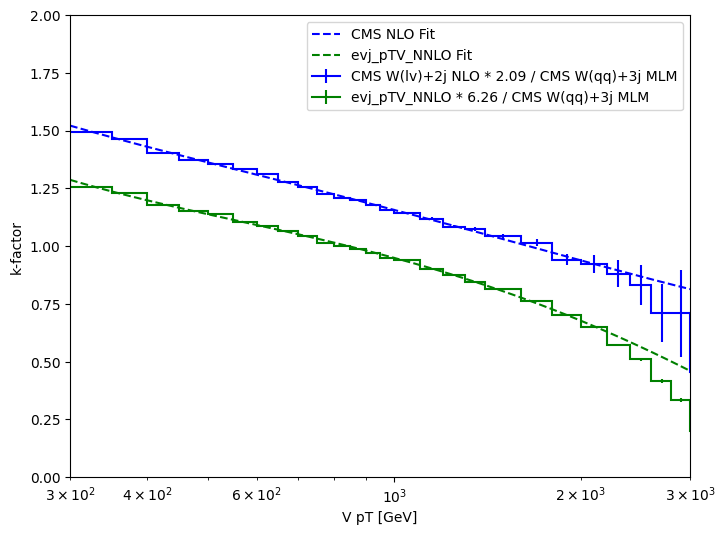

In [65]:
fig, ax = plt.subplots(figsize=(8, 6))

tofxfx = ratio(
    scale(cms_wlv_nlo["Vpt"], 2.09),
    cms_wqqj_mlm["Vpt"],
)
tofxfx_fit = polyfit(tofxfx[hist.loc(300):], 4)
w_tofxfx_corr = Correction(
    name="W_MLMtoFXFX",
    version=1,
    description="k_CMS(vpt), or CMS W(lv)+2j NLO * 2.09 / CMS W(qq)+3j MLM",
    inputs=[vptvar],
    output=Variable(name="out", type="real", description="Multiplicative k-factor"),
    data={
        "nodetype": "binning",
        "input": "vpt",
        "edges": [299, 300, 3000, 3001],
        "content": [
            np.polyval(tofxfx_fit, np.log(300)),
            {
                "nodetype": "formula",
                "variables": ["vpt"],
                "parser": "TFormula",
                "expression": horner(tofxfx_fit, "log(x)"),
            },
            np.polyval(tofxfx_fit, np.log(3000)),
        ],
        "flow": "clamp",
    },
)
tofxfx.plot1d(ax=ax, label="CMS W(lv)+2j NLO * 2.09 / CMS W(qq)+3j MLM", color="b")
ax.plot(x, evaluator(w_tofxfx_corr)(x), label="CMS NLO Fit", color="b", linestyle="--")


tolindert = ratio(
    scale(evj["evj_pTV_NNLO"], 6.26),
    cms_wqqj_mlm["Vpt"],
)
tolindert_fit = polyfit(tolindert[hist.loc(300):], 4)
w_tolindert_corr = Correction(
    name="W_MLMtoNNLOQCD",
    version=1,
    description="k_CMS(vpt), or evj_pTV_NNLO * 6.26 / CMS W(qq)+3j MLM",
    inputs=[vptvar],
    output=Variable(name="out", type="real", description="Multiplicative k-factor"),
    data={
        "nodetype": "binning",
        "input": "vpt",
        "edges": [299, 300, 3000, 3001],
        "content": [
            np.polyval(tolindert_fit, np.log(300)),
            {
                "nodetype": "formula",
                "variables": ["vpt"],
                "parser": "TFormula",
                "expression": horner(tolindert_fit, "log(x)"),
            },
            np.polyval(tolindert_fit, np.log(3000)),
        ],
        "flow": "clamp",
    },
)
tolindert.plot1d(ax=ax, label="evj_pTV_NNLO * 6.26 / CMS W(qq)+3j MLM", color="g")
ax.plot(x, evaluator(w_tolindert_corr)(x), label="evj_pTV_NNLO Fit", color="g", linestyle="--")

ax.set_xscale("log")
ax.set_ylim(0, 2)
ax.set_xlim(300, 3000)
ax.set_ylabel("k-factor")
ax.set_xlabel("V pT [GeV]")
ax.legend()

fig.savefig(f"{plotdir}/W_kCMS.pdf")

In [66]:
den = lindert["evj_pTV_LO"].values() * lindert["evj_pTV_K_NLO"].values()

def binning(idx, shift):
    epsilon = np.zeros(113)
    epsilon[idx] = shift
    return {
        "nodetype": "binning",
        "input": "vpt",
        "edges": list(vptproc.edges),
        "content": list(evj_qcd(epsilon) / den),
        "flow": "clamp",
    }


w_fixedorder_corr = Correction(
    name="W_FixedOrderComponent",
    version=1,
    description="W boson K_TH(vpt, ...) / K_NLO(vpt, ...)",
    inputs=[Variable(name="systematic", type="string"), vptvar],
    output=Variable(name="out", type="real", description="Multiplicative k-factor"),
    data={
        "nodetype": "category",
        "input": "systematic",
        "content": [
            {"key": "nominal", "value": binning(0, 0)},
            {"key": "d1K_NLO_up", "value": binning(0, +1)},
            {"key": "d2K_NLO_up", "value": binning(1, +1)},
            {"key": "d3K_NLO_up", "value": binning(2, +1)},
            {"key": "d1K_NLO_down", "value": binning(0, -1)},
            {"key": "d2K_NLO_down", "value": binning(1, -1)},
            {"key": "d3K_NLO_down", "value": binning(2, -1)},
            {"key": "d1kappa_EW_up", "value": binning(109, +1)},
            {"key": "W_d2kappa_EW_up", "value": binning(110, +1)},
            {"key": "W_d3kappa_EW_up", "value": binning(111, +1)},
            {"key": "d1kappa_EW_down", "value": binning(109, -1)},
            {"key": "W_d2kappa_EW_down", "value": binning(110, -1)},
            {"key": "W_d3kappa_EW_down", "value": binning(111, -1)},
        ]
    },
)

In [67]:
cset = CorrectionSet(
    schema_version=2,
    corrections=[
        z_tofxfx_corr,
        z_tolindert_corr,
        z_fixedorder_corr,
        w_tofxfx_corr,
        w_tolindert_corr,
        w_fixedorder_corr,
    ]
)

import rich

rich.print(cset)
with open("data/vjets/vjets_corrections.json", "w") as fout:
    fout.write(cset.json(exclude_unset=True))



CorrectionSet (schema v2)
No description
📂
├── 📈 Z_MLMtoFXFX (v1)
│   k_CMS(ptv), or CMS Z(ll)+2j NLO * 6.93 / CMS Z(qq)+4j MLM
│   Node counts: Binning: 1, Formula: 1
│   ╭───────────────────────────────────────── ▶ input ─────────────────────────────────────────╮
│   │ vpt (real)                                                                                │
│   │ Generated boson pT (status 62: fromHardProcess, isLastCopy) or sum(leptons).pt if virtual │
│   │ Range: [-inf, inf), overflow ok                                                           │
│   ╰───────────────────────────────────────────────────────────────────────────────────────────╯
│   ╭─────── ◀ output ────────╮
│   │ out (real)              │
│   │ Multiplicative k-factor │
│   ╰─────────────────────────╯
├── 📈 Z_MLMtoNNLOQCD (v1)
│   eej_pTV_NNLO * 20.8 / CMS Z(qq)+4j MLM
│   Node counts: Binning: 1, Formula: 1
│   ╭───────────────────────────────────────── ▶ input ─────────────────────────────────────────╮
│   │ vpt (real)                                                                                │
│   │ Generated boson pT (status 62: fromHardProcess, isLastCopy) or sum(leptons).pt if virtual │
│   │ Range: [-inf, inf), overflow ok                                                           │
│   ╰───────────────────────────────────────────────────────────────────────────────────────────╯
│   ╭─────── ◀ output ────────╮
│   │ out (real)              │
│   │ Multiplicative k-factor │
│   ╰─────────────────────────╯
├── 📈 Z_FixedOrderComponent (v1)
│   Z boson K_TH(vpt, ...) / K_NLO(vpt, ...)
│   Node counts: Category: 1, Binning: 13
│   ╭────────────────────────────────────────────────── ▶ input ──────────────────────────────────────────────────╮
│   │ systematic (string)                                                                                         │
│   │ No description                                                                                              │
│   │ Values: Z_d2kappa_EW_down, Z_d2kappa_EW_up, Z_d3kappa_EW_down, Z_d3kappa_EW_up, d1K_NLO_down, d1K_NLO_up,   │
│   │ d1kappa_EW_down, d1kappa_EW_up, d2K_NLO_down, d2K_NLO_up, d3K_NLO_down, d3K_NLO_up, nominal                 │
│   ╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────╯
│   ╭────────────────────────────────────────────────── ▶ input ──────────────────────────────────────────────────╮
│   │ vpt (real)                                                                                                  │
│   │ Generated boson pT (status 62: fromHardProcess, isLastCopy) or sum(leptons).pt if virtual                   │
│   │ Range: [30.0, 6500.0), overflow ok                                                                          │
│   ╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────╯
│   ╭─────── ◀ output ────────╮
│   │ out (real)              │
│   │ Multiplicative k-factor │
│   ╰─────────────────────────╯
├── 📈 W_MLMtoFXFX (v1)
│   k_CMS(vpt), or CMS W(lv)+2j NLO * 2.09 / CMS W(qq)+3j MLM
│   Node counts: Binning: 1, Formula: 1
│   ╭───────────────────────────────────────── ▶ input ─────────────────────────────────────────╮
│   │ vpt (real)                                                                                │
│   │ Generated boson pT (status 62: fromHardProcess, isLastCopy) or sum(leptons).pt if virtual │
│   │ Range: [-inf, inf), overflow ok                                                           │
│   ╰───────────────────────────────────────────────────────────────────────────────────────────╯
│   ╭─────── ◀ output ────────╮
│   │ out (real)              │
│   │ Multiplicative k-factor │
│   ╰─────────────────────────╯
├── 📈 W_MLMtoNNLOQCD (v1)
│   k_CMS(vpt), or evj_pTV_NNLO * 6.26 / CMS W(qq)+3j MLM
│   Node counts: Binning: 1, Formula: 1
│   ╭───────────────────────────────────────── ▶ input ─────────────────────────────────────────

/tmp/ipykernel_1344019/225034498.py:17: PydanticDeprecatedSince20: The `json` method is deprecated; use `model_dump_json` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  fout.write(cset.json(exclude_unset=True))
